In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
X,y = load_diabetes(return_X_y=True)
data_df = pd.DataFrame(X)
data_df["target"]=pd.DataFrame(y)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
data_df.shape

(442, 11)

In [ ]:
data_df.info()
data_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       442 non-null    float64
 1   1       442 non-null    float64
 2   2       442 non-null    float64
 3   3       442 non-null    float64
 4   4       442 non-null    float64
 5   5       442 non-null    float64
 6   6       442 non-null    float64
 7   7       442 non-null    float64
 8   8       442 non-null    float64
 9   9       442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
data_df.describe()

,0,1,2,3,4,5,6,7,8,9,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


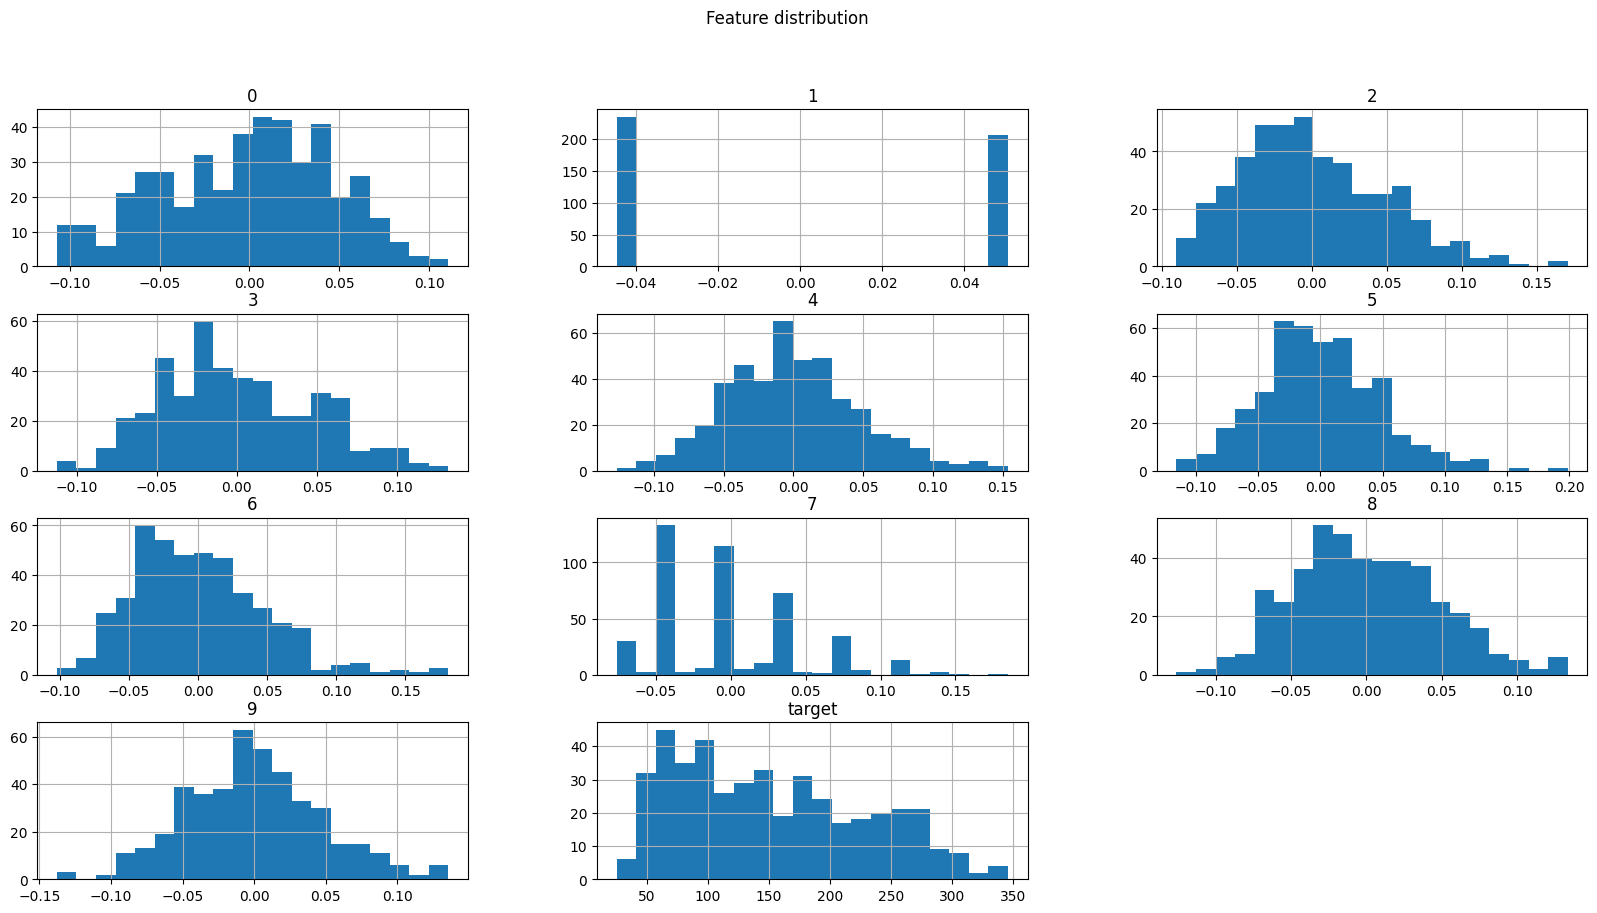

In [ ]:
data_df.hist(figsize=(20,10),bins=20)
plt.suptitle("Feature distribution")
plt.show()


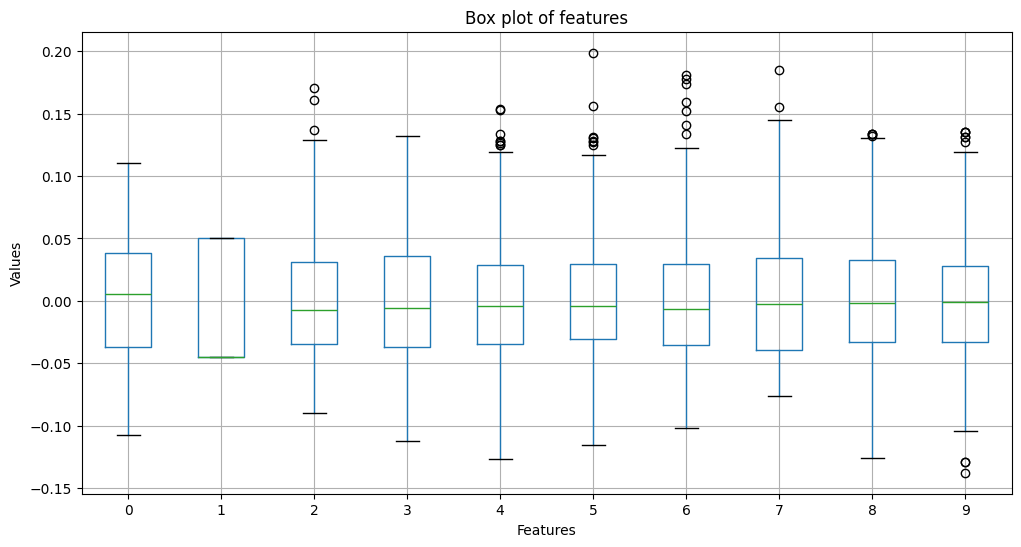

In [ ]:
plt.figure(figsize=(12,6))
X_df = data_df.drop("target",axis=1)
X_df.boxplot()
plt.title("Box plot of features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

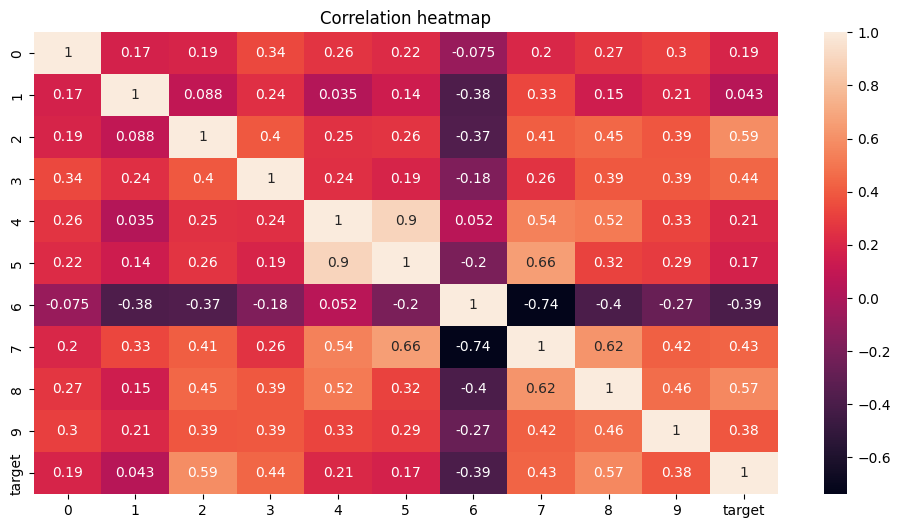

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(data_df.corr(),annot=True)
plt.title("Correlation heatmap")
plt.show()

In [ ]:
corr_target = data_df.corr()["target"].sort_values(ascending=False)
corr_target

,target
target,1.000000
2,0.586450
8,0.565883
3,0.441482
7,0.430453
9,0.382483
4,0.212022
0,0.187889
5,0.174054
1,0.043062


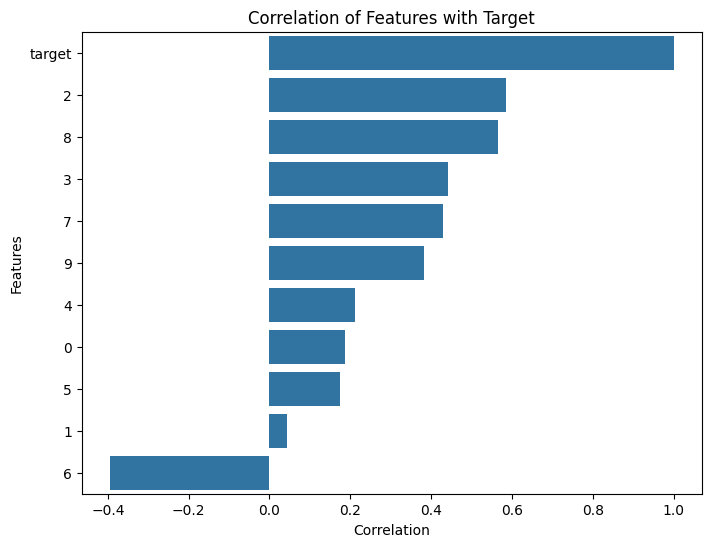

In [ ]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index
)

plt.title("Correlation of Features with Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

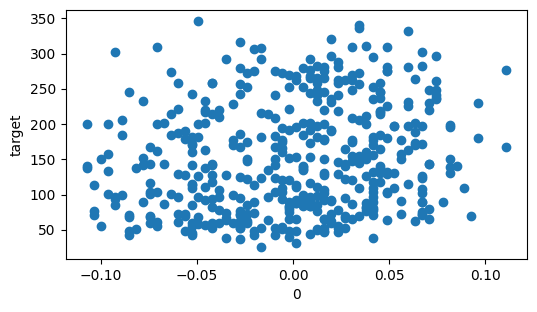

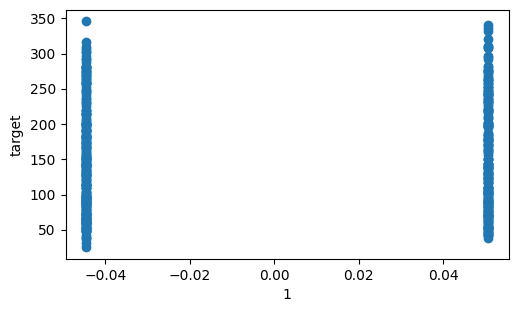

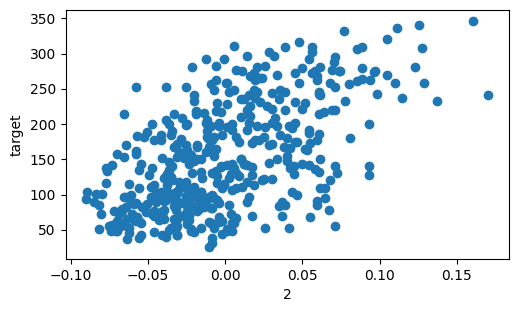

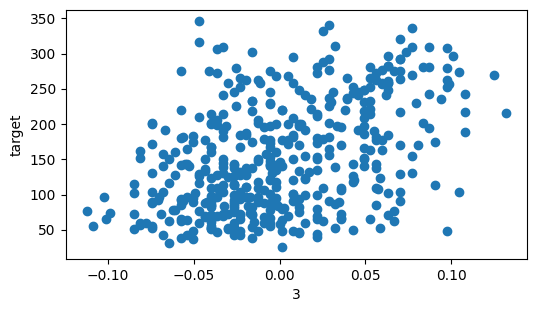

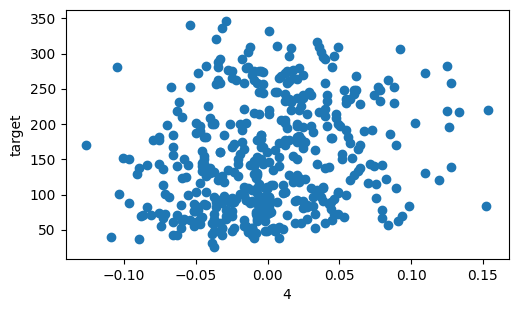

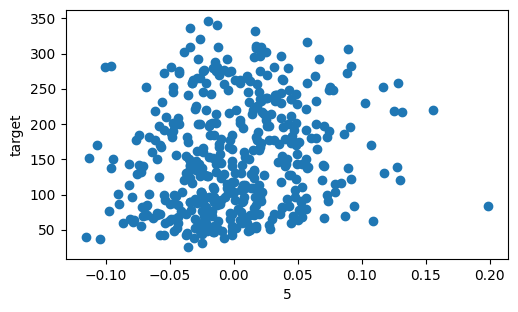

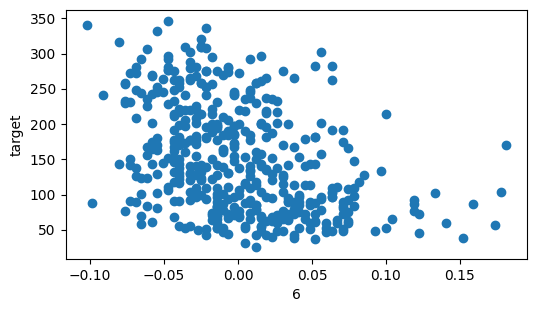

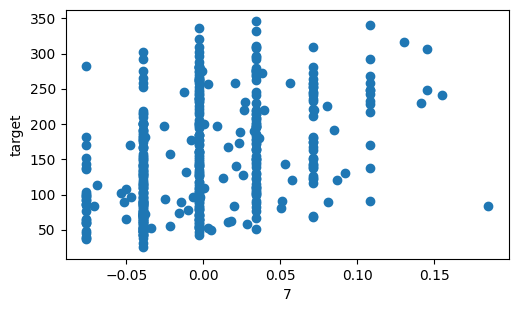

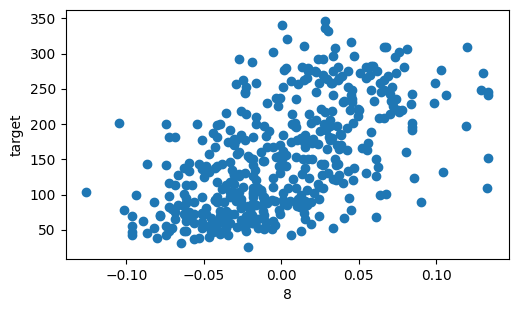

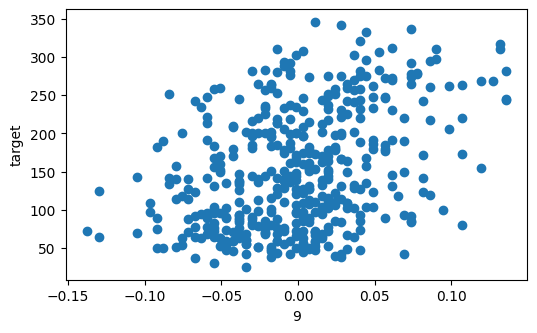

In [ ]:
for i in range(10):
  plt.figure(figsize=(15,12))
  plt.subplot(4,3,i+1)
  plt.scatter(data_df.iloc[:,i],data_df.iloc[:,-1])
  plt.xlabel(data_df.columns[i])
  plt.ylabel(data_df.columns[-1])
  plt.tight_layout()
  plt.show()

Training the model


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
print(X_train.shape[0],X_test.shape[0])
print(X_train.shape)

331 111
(331, 10)


In [ ]:
pd.DataFrame(X_train).describe().T

,count,mean,std,min,25%,50%,75%,max
0,331.0,0.001015,0.046460,-0.107226,-0.034575,0.005383,0.038076,0.110727
1,331.0,0.000283,0.047654,-0.044642,-0.044642,-0.044642,0.050680,0.050680
2,331.0,0.002325,0.047211,-0.089197,-0.030996,-0.005128,0.033673,0.160855
3,331.0,0.001295,0.047900,-0.112399,-0.036656,-0.005670,0.035644,0.132044
4,331.0,0.000559,0.048134,-0.108893,-0.035280,-0.002945,0.027326,0.153914
5,331.0,0.000048,0.048304,-0.115613,-0.032316,-0.003819,0.028905,0.198788
6,331.0,-0.000595,0.047079,-0.102307,-0.032356,-0.006584,0.026550,0.181179
7,331.0,0.000863,0.048337,-0.076395,-0.039493,-0.002592,0.034309,0.185234
8,331.0,0.001738,0.048045,-0.126097,-0.031368,-0.000612,0.034866,0.133597
9,331.0,0.003252,0.047479,-0.137767,-0.030072,0.003064,0.032059,0.135612


In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
def evaluate(y_true,y_pred):
  r2 = r2_score(y_true,y_pred)
  mse = mean_squared_error(y_true,y_pred)
  smse = np.sqrt(mse)
  return r2,mse,smse
train_r2, train_mse, train_rmse = evaluate(y_train, train_pred)
test_r2, test_mse, test_rmse = evaluate(y_test, test_pred)

print("Train R2 Score:", train_r2)
print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Test R2 Score:", test_r2)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

Train R2 Score: 0.519034189167905
Train MSE: 2907.2577640101085
Train RMSE: 53.918992609377526
Test R2 Score: 0.4849058889476756
Test MSE: 2848.3106508475053
Test RMSE: 53.369566710321955


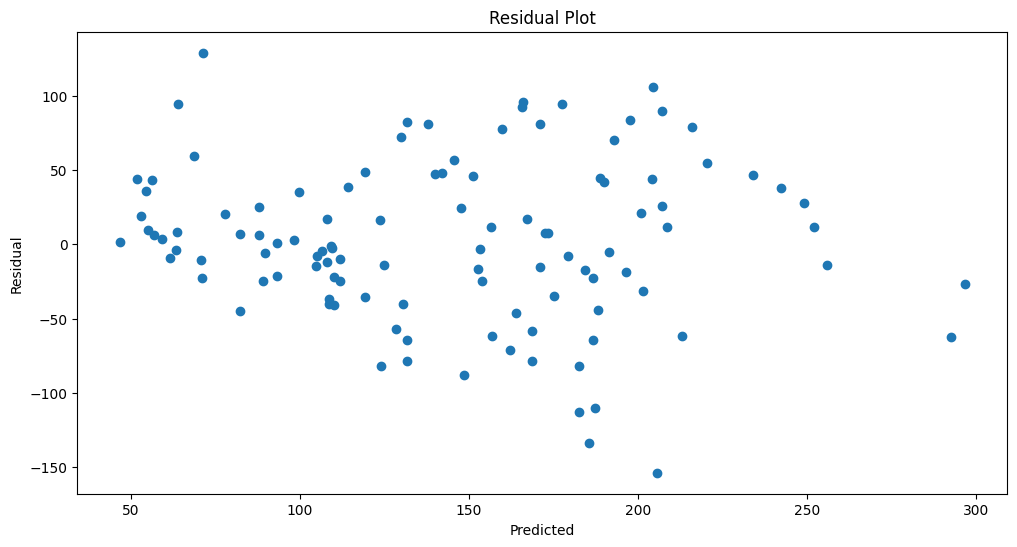

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(test_pred , y_test-test_pred)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

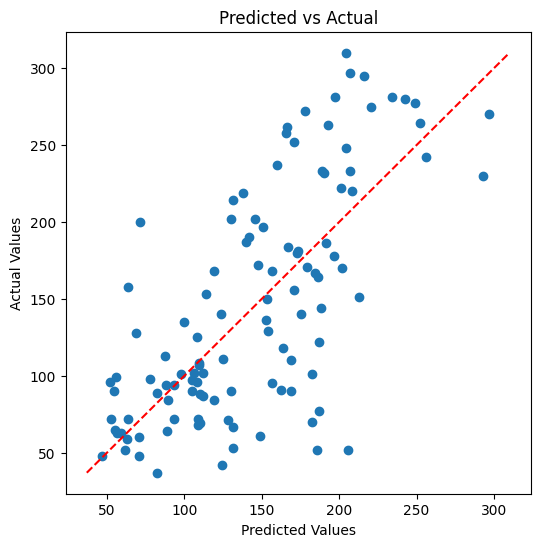

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(test_pred, y_test)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Predicted vs Actual")
plt.show()

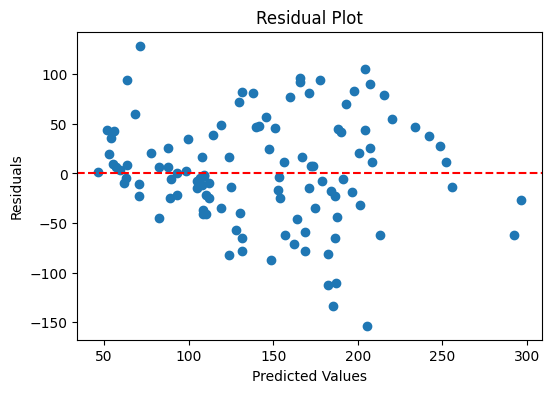

In [ ]:
residuals = y_test - test_pred

plt.figure(figsize=(6,4))
plt.scatter(test_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Experimenting with polynomial features

In [ ]:
degree = 4
poly_features = PolynomialFeatures(degree=degree)
X_train_poly=poly_features.fit_transform(X_train)
print(X_train_poly.shape)
X_test_poly = poly_features.transform(X_test)
print(X_test_poly.shape)
model_poly = LinearRegression()
model_poly.fit(X_train_poly,y_train)
poly_train_pred = model_poly.predict(X_train_poly)
poly_test_pred = model_poly.predict(X_test_poly)
poly_train_r2, poly_train_mse, poly_train_rmse = evaluate(y_train, poly_train_pred)
poly_test_r2, poly_test_mse, poly_test_rmse = evaluate(y_test, poly_test_pred)
print("Train R2 Score:", poly_train_r2)
print("Train MSE:", poly_train_mse)
print("Train RMSE:", poly_train_rmse)
print("Test R2 Score:", poly_test_r2)
print("Test MSE:", poly_test_mse)
print("Test RMSE:", poly_test_rmse)




(331, 1001)
(111, 1001)
Train R2 Score: 1.0
Train MSE: 1.1656255586352321e-21
Train RMSE: 3.414125889060379e-11
Test R2 Score: -29.414739276875167
Test MSE: 168184.07348530792
Test RMSE: 410.10251582416305


differnce between the evaluated values

In [ ]:
print(poly_train_r2-poly_test_r2)
print(poly_train_mse-poly_test_mse)
print(poly_train_rmse-poly_test_rmse)

0.18057338389110256
-795.0204652497964
-7.550079437997638


checking differnce between the valuse predicted by linear regression and polynomial regression

In [ ]:
model_Pred_diff_LP_train = poly_train_pred-train_pred
model_Pred_diff_LP_test = poly_test_pred-test_pred
model_r2_diff_LP_train = poly_train_r2-train_r2
model_r2_diff_LP_test = poly_test_r2-test_r2
model_mse_diff_LP_train = poly_train_mse-train_mse
model_mse_diff_LP_test = poly_test_mse-test_mse
model_rmse_diff_LP_train = poly_train_rmse-train_rmse
model_rmse_diff_LP_test = poly_test_rmse-test_rmse
print(model_r2_diff_LP_train)
print(model_r2_diff_LP_test)
print(model_mse_diff_LP_train)
print(model_mse_diff_LP_test)
print(model_rmse_diff_LP_train)
print(model_rmse_diff_LP_test)

print(model_Pred_diff_LP_train.mean())
print(model_Pred_diff_LP_test.mean())

0.08578114066914999
-0.060663943001723175
-518.5147916950191
335.4527867173806
-5.04422435094903
3.0552809861041794
2.967535582824056e-13
6.715541227399253


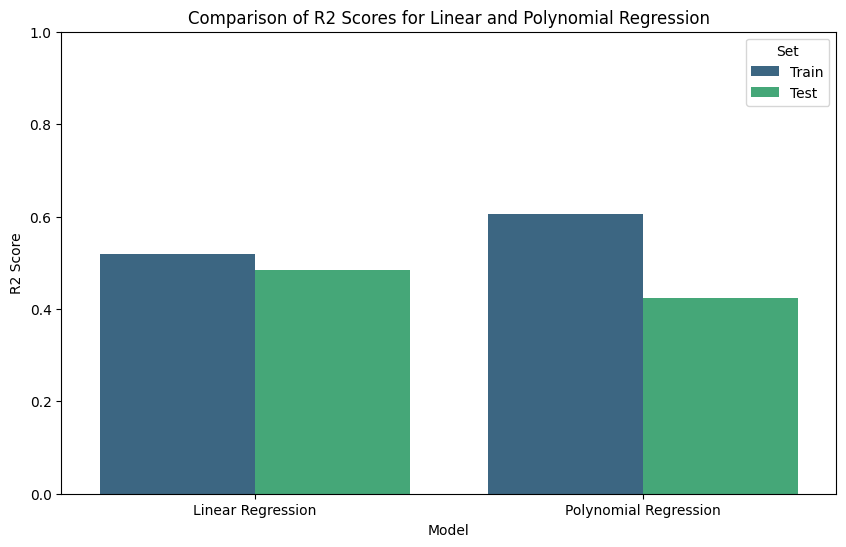

In [ ]:
r2_scores = pd.DataFrame({
    'Model': ['Linear Regression', 'Linear Regression', 'Polynomial Regression', 'Polynomial Regression'],
    'Set': ['Train', 'Test', 'Train', 'Test'],
    'R2_Score': [train_r2, test_r2, poly_train_r2, poly_test_r2]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2_Score', hue='Set', data=r2_scores, palette='viridis')
plt.title('Comparison of R2 Scores for Linear and Polynomial Regression')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.show()

RidgeRegression


In [ ]:
alpha =0.1
model_Ridge = Ridge(alpha=alpha)
model_Ridge.fit(X_train_poly,y_train)
Ridge_train_pred = model_Ridge.predict(X_train_poly)
Ridge_test_pred = model_Ridge.predict(X_test_poly)
Ridge_train_r2, Ridge_train_mse, Ridge_train_rmse = evaluate(y_train, Ridge_train_pred)
Ridge_test_r2, Ridge_test_mse, Ridge_test_rmse = evaluate(y_test, Ridge_test_pred)
print("Train R2 Score:", Ridge_train_r2)
print("Train MSE:", Ridge_train_mse)
print("Train RMSE:", Ridge_train_rmse)
print("Test R2 Score:", Ridge_test_r2)
print("Test MSE:", Ridge_test_mse)
print("Test RMSE:", Ridge_test_rmse)
print(model_Ridge.intercept_)
print(model_Ridge.coef_)

Train R2 Score: 0.5149371236445714
Train MSE: 2932.0229869929276
Train RMSE: 54.148157743296565
Test R2 Score: 0.49537663053177616
Test MSE: 2790.4106979333937
Test RMSE: 52.824338121110365
150.8412473919753
[ 0.00000000e+00  5.61640662e+01 -2.00761534e+02  4.91159488e+02
  3.39058412e+02 -1.17189044e+02 -7.71706298e+01 -2.19068512e+02
  1.48076559e+02  3.65984947e+02  6.05148593e+01  4.33131254e+01
  5.57548320e+01  1.35786685e+01  4.13146762e+01 -5.96892341e+00
 -1.73588987e+01 -6.86957418e+00  1.21993549e+01  3.06257247e+01
  2.41040376e+01 -1.21229496e+00  2.07402224e+01  3.99782753e+01
  2.03799328e+00 -1.08181425e+01  3.69121979e+00 -3.95051015e+00
  2.28488769e+01  2.21906915e+01  7.16026245e+01  5.38793555e+01
 -9.51702889e+00  4.15102113e-01 -3.20440603e+01  2.44346844e+01
  1.53836171e+01  4.56149436e+01  3.06817779e+01  7.10151417e+00
  3.29094927e+00 -2.80418971e+00  2.82972660e+00  1.86595641e+01
  4.30337198e+00  1.13982000e+01  6.71074797e+00  1.96470477e+01
 -1.24174131

Polynomial Regression with Varying Degrees

In [ ]:
degrees = [1,2, 3, 4]

poly_train_r2_scores = []
poly_test_r2_scores = []

for d in degrees:
    poly_features = PolynomialFeatures(degree=d)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)

    poly_train_pred = model_poly.predict(X_train_poly)
    poly_test_pred = model_poly.predict(X_test_poly)

    poly_train_r2, _, _ = evaluate(y_train, poly_train_pred)
    poly_test_r2, _, _ = evaluate(y_test, poly_test_pred)

    poly_train_r2_scores.append(poly_train_r2)
    poly_test_r2_scores.append(poly_test_r2)


In [ ]:
fig = plt.figure(figsize=(10, 6))
plt.plot(degrees, poly_train_r2_scores, marker='o', label='Train R²')
plt.plot(degrees, poly_test_r2_scores, marker='x', label='Test R²')

plt.title('Train/Test R² vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
alphas = [0.01, 0.1, 1, 2, 10, 100]

train_r2 = [
    0.5371473311770835,
    0.5149371236445714,
    0.42791319284620444,
    0.35502205037099654,
    0.15099790967423465,
    0.020217377929379388
]

test_r2 = [
    0.5050889280291726,
    0.49537663053177616,
    0.43870182398674673,
    0.3715885498080371,
    0.15644986167540842,
    0.009089658750056961
]

train_rmse = [
    52.83995637060834,
    54.148157743296565,
    58.80518666287205,
    62.43916695620649,
    71.63727316614909,
    76.95724867689958
]

test_rmse = [
    52.313523161299436,
    52.824338121110365,
    55.7118012407043,
    58.94845532339096,
    68.29766170166955,
    74.02315046422555
]

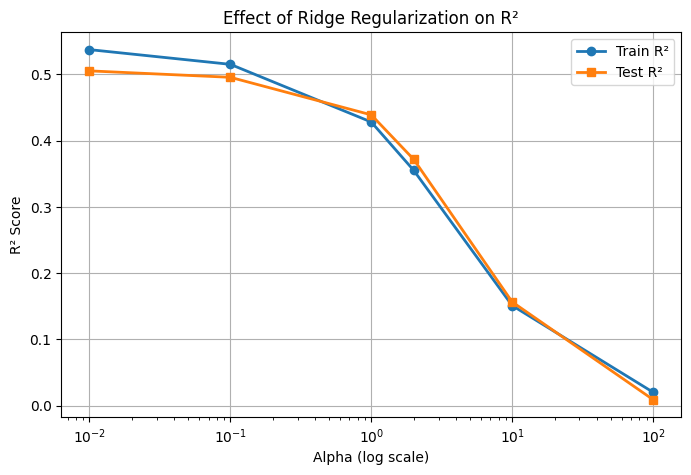

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(alphas, train_r2, marker='o', linewidth=2, label='Train R²')
plt.plot(alphas, test_r2, marker='s', linewidth=2, label='Test R²')

plt.xscale('log')

plt.title("Effect of Ridge Regularization on R²")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R² Score")

plt.grid(True)
plt.legend()

plt.show()

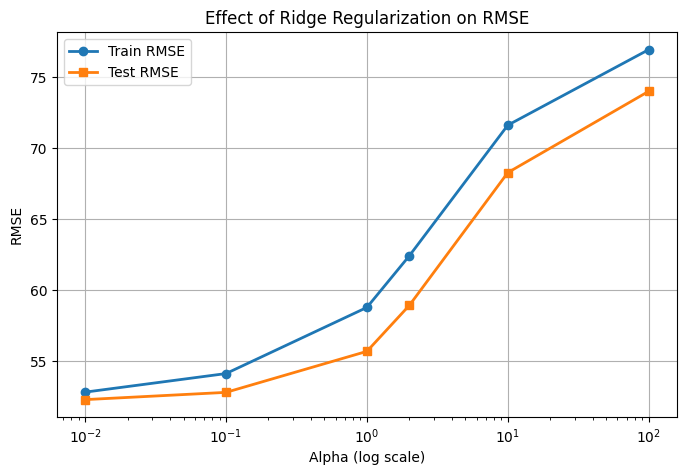

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(alphas, train_rmse, marker='o', linewidth=2, label='Train RMSE')
plt.plot(alphas, test_rmse, marker='s', linewidth=2, label='Test RMSE')

plt.xscale('log')

plt.title("Effect of Ridge Regularization on RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")

plt.grid(True)
plt.legend()

plt.show()